<a href="https://colab.research.google.com/github/Ujjwal-006/DeepLearning-Problem/blob/main/Binary_Classifier_on_Wisconsin_Breast_Cancer_useing_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [4]:
df = pd.read_csv('/content/data.csv')

# Drop useless columns ('id' and the trailing empty 'Unnamed: 32')
columns_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
df = df.drop(columns=columns_to_drop)

In [5]:
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
    y = df['diagnosis'].values
    X = df.drop(columns=['diagnosis']).values
else:
    # Fallback if your target is already the last column
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

In [6]:
# Ensure all feature data are float numbers
X = X.astype(float)
y = y.astype(float)

In [7]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std = np.where(std == 0, 1e-15, std)  # Avoid division by zero

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [9]:
n_samples, n_features = X_train.shape
W = np.zeros(n_features)
b = 0.0

epochs = 1000
lr = 0.1
losses = []

In [10]:
for epoch in range(epochs):
    # Forward pass
    z = np.dot(X_train, W) + b
    # Clip z to prevent numerical overflow in exp(-z)
    z = np.clip(z, -250, 250)
    p = 1 / (1 + np.exp(-z))

    # Compute BCE loss safely
    eps = 1e-15
    loss = -np.mean(y_train * np.log(p + eps) + (1 - y_train) * np.log(1 - p + eps))
    losses.append(loss)

In [11]:
# Gradients
dz = p - y_train
dW = np.dot(X_train.T, dz) / n_samples
db = np.mean(dz)

W -= lr * dW
b -= lr * db

In [12]:
z_test = np.clip(np.dot(X_test, W) + b, -250, 250)
p_test = 1 / (1 + np.exp(-z_test))
y_pred = (p_test >= 0.5).astype(int)

print(f"--- Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")

--- Evaluation Metrics ---
Accuracy:  96.49%
Precision: 0.9535
Recall:    0.9535
F1 Score:  0.9535


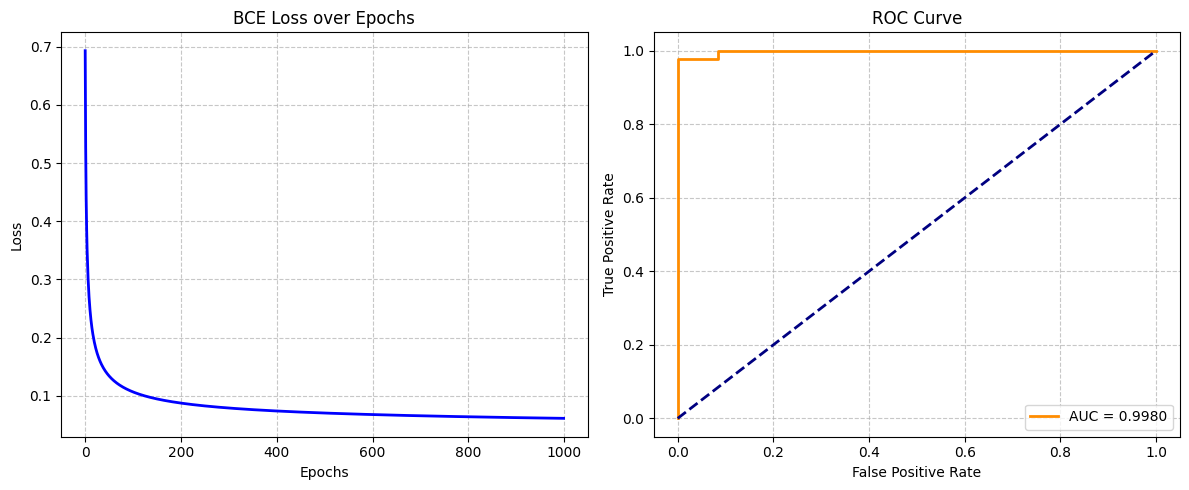

In [16]:
ig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Loss Curve
ax1.plot(range(len(losses)), losses, color='blue', linewidth=2)
ax1.set_title('BCE Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, p_test)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_title('ROC Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()